# 14_损失函数-KL散度

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这里，咱们将会介绍损失函数方面的，KL散度\~

KL散度的全称是 **Kullback-Leibler Divergence**，也叫 **相对熵**。

KL散度是用来衡量「两个概率分布之间有多不一样」的一个工具。

打个比方：

- 假设你有两个袋子：袋子P和袋子Q。
- 每个袋子里都有颜色球：红、绿、蓝，每种颜色的球数量不一样。
- KL散度就是告诉你：如果你以为你是在用Q袋子抓球，其实你在用P袋子，那么你每次抓错的‘代价’有多大？

### 关键词

- 它不是对称的（$KL(P \parallel Q) \ne KL(Q \parallel P)$）。
- 它越小，说明两个分布越相似；KL散度为0，表示两个分布一模一样。
- 它是个**非负数**（≥0）。
- 它常用作**损失函数**，比如在**机器学习中的分类模型、变分自编码器**里。

## KL散度的数学定义

对于两个概率分布 P(x) 和 Q(x)，KL散度定义为：


$$
D_{KL}(P \parallel Q) = \sum_x P(x) \log \left( \frac{P(x)}{Q(x)} \right)
$$


如果是连续型分布，就变成积分形式：


$$
D_{KL}(P \parallel Q) = \int P(x) \log \left( \frac{P(x)}{Q(x)} \right) dx
$$


其中：

- P(x)：真实分布（你实际使用的袋子）
- Q(x)：估计分布（你以为你在用的袋子）

## 从信息论角度理解

KL散度可以理解为「用错误分布 Q 去描述真实分布 P 所造成的信息损失」。

信息量的单位：**比特（bit）** 或 **纳特（nat）**，取决于对数底是2还是e。

### 信息量直观解释：

- 事件概率越小，信息量越大。
- 概率为 p 的事件，它带来的信息量是 $-\log(p)$

那么，用 Q(x) 估计 P(x) 的代价就是：


$$
\text{信息损失} = \text{用 Q 估计时的信息量} - \text{P 自己的信息量}
$$


$$
= -\sum_x P(x) \log Q(x) + \sum_x P(x) \log P(x)
$$


整理后：


$$
D_{KL}(P \parallel Q) = \sum_x P(x) \log \left( \frac{P(x)}{Q(x)} \right)
$$


## 推导过程（从交叉熵和熵出发）

#### 熵（Entropy）：


$$
H(P) = -\sum_x P(x) \log P(x)
$$


表示分布 P 的**平均信息量**。

#### 交叉熵（Cross Entropy）：


$$
H(P, Q) = -\sum_x P(x) \log Q(x)
$$


表示：如果真实分布是 P，你用 Q 来编码，会花费多少信息量。

#### KL散度与它们的关系：


$$
D_{KL}(P \parallel Q) = H(P, Q) - H(P)
$$


即：

> KL散度 = 你“错误估计”所付出的额外信息代价

## 一个例子

假设：

- 真实分布 P：

  - 猫：70%
  - 狗：30%
- 模型估计的分布 Q：

  - 猫：60%
  - 狗：40%

计算 KL(P‖Q)：


$$
D_{KL}(P \parallel Q) = 0.7 \log\left( \frac{0.7}{0.6} \right) + 0.3 \log\left( \frac{0.3}{0.4} \right)
$$


计算后：


$$
D_{KL} \approx 0.7 \cdot 0.154 + 0.3 \cdot (-0.125) = 0.1078 - 0.0375 = 0.0703
$$


这个值告诉你：「你用 Q 去估计 P，平均每次预测多花了 0.07 nat 的信息量」。

## KL散度作为损失函数的意义

#### 举个场景：分类模型

- 模型输出一个预测分布 Q（比如 [0.1, 0.7, 0.2] 表示三类的概率）
- 真实标签用 one-hot 编码的分布 P（比如 [0, 1, 0]）

那么：


$$
D_{KL}(P \parallel Q) = \sum_i P(i) \log \left( \frac{P(i)}{Q(i)} \right)
$$


由于只有一个类是1，其它为0，就变成：


$$
D_{KL} = \log \left( \frac{1}{Q_{\text{真实类}}} \right) = -\log(Q_{\text{真实类}})
$$


所以，**KL散度最终退化成了交叉熵损失函数**。

## KL散度的算法流程

KL散度在实际应用中的步骤：

### 1. 得到两个分布：

- 真值分布 P（可能是标签）
- 模型估计分布 Q（通过 softmax 输出）

### 2. 对每个样本计算 KL 散度：


$$
D_{KL}(P \parallel Q) = \sum_i P(i) \log \left( \frac{P(i)}{Q(i)} \right)
$$


### 3. 对整个数据集取平均作为总损失

## 小结

| 项目 | 内容 |
|-|-|
| 名称 | Kullback-Leibler Divergence（KL散度） |
| 本质 | 衡量两个概率分布的“差距” |
| 公式 | $D_{KL}(P \parallel Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}$ |
| 最小值 | 0（当P=Q） |
| 方向性 | 非对称（注意 P 和 Q 的顺序） |
| 与交叉熵关系 | KL = 交叉熵 - 熵 |
| 用途 | 模型损失函数、分布拟合、VAE中正则项等 |

## 完整案例

设想我们有两个连续概率分布：

- **真实分布 P**：是一个混合正态分布，代表真实数据分布。
- **拟合分布 Q**：是一个单一正态分布，我们希望通过调整Q的参数，使得它尽可能逼近P。

我们将通过KL散度度量Q相对于P的差异，并使用梯度下降优化Q的参数（均值和标准差），使KL散度最小。

最终将展示拟合效果及KL散度的变化过程。

Optimized mu: 0.4563, sigma: 2.7399


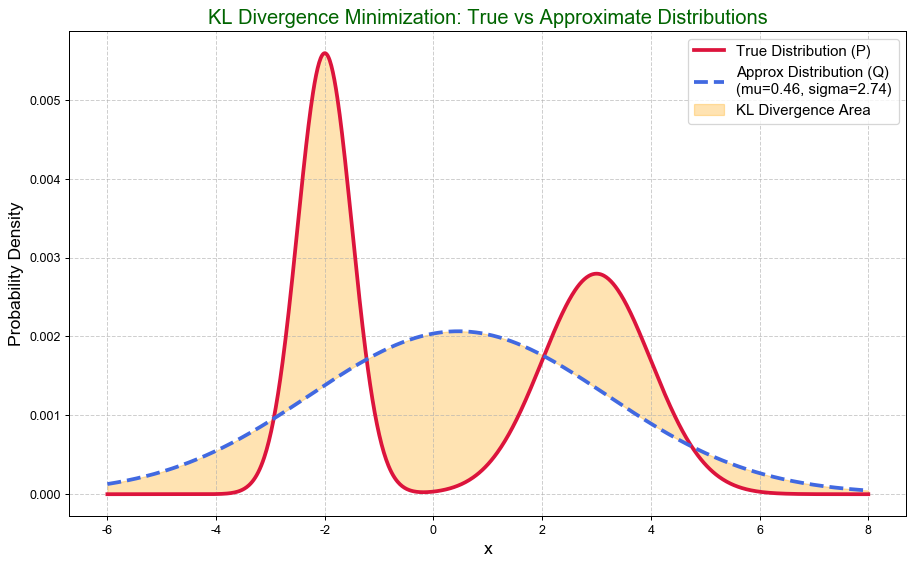

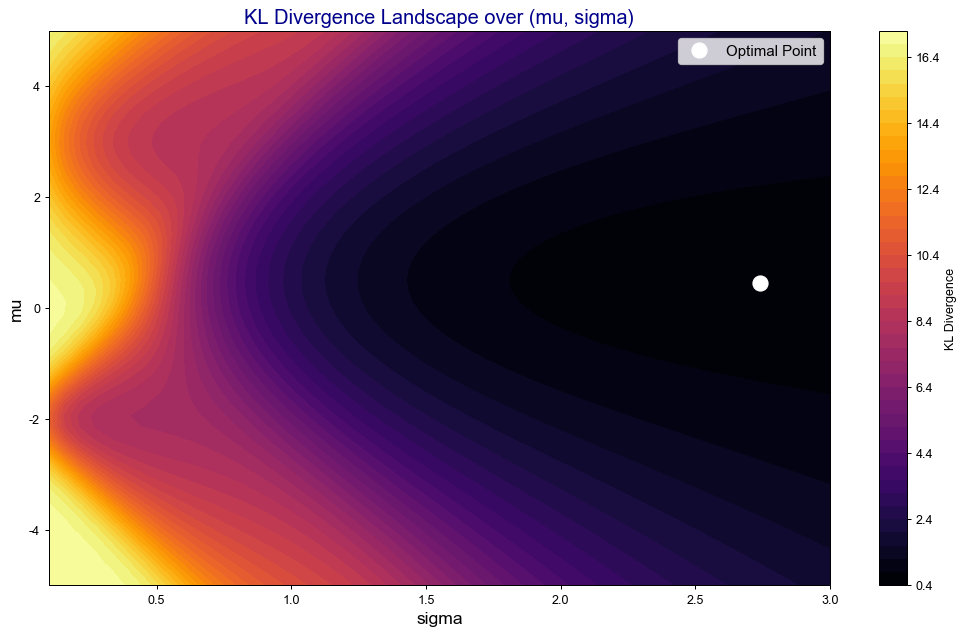

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

np.random.seed(42)

# 1. 定义真实分布 P: 混合高斯分布
def true_distribution(x):
    # 50% N(-2, 0.5^2) + 50% N(3, 1^2)
    return 0.5 * norm.pdf(x, loc=-2, scale=0.5) + 0.5 * norm.pdf(x, loc=3, scale=1)

# 2. 定义拟合分布 Q: 单高斯分布，参数待优化
def approx_distribution(x, mu, sigma):
    return norm.pdf(x, loc=mu, scale=sigma)

# 3. 离散点区间及采样
x_vals = np.linspace(-6, 8, 1000)

# 真实分布概率值
p_vals = true_distribution(x_vals)
p_vals = p_vals / np.sum(p_vals)  # 归一化概率

# 4. 定义KL散度计算函数
def kl_divergence(p, q):
    epsilon = 1e-10  # 防止log(0)
    return np.sum(p * np.log(p / (q + epsilon)))

# 5. 定义目标函数，用于优化Q的参数 (mu, sigma) 使KL散度最小
def objective(params):
    mu, sigma = params
    if sigma <= 0:
        return np.inf  # 标准差必须大于0
    q_vals = approx_distribution(x_vals, mu, sigma)
    q_vals = q_vals / np.sum(q_vals)  # 归一化
    return kl_divergence(p_vals, q_vals)

# 6. 初始参数及优化
init_params = [0, 1]  # 初始均值和标准差
result = minimize(objective, init_params, method='L-BFGS-B', bounds=[(-5,5), (0.1,5)])

opt_mu, opt_sigma = result.x

print(f"Optimized mu: {opt_mu:.4f}, sigma: {opt_sigma:.4f}")

# 7. 计算拟合后的概率分布
q_opt_vals = approx_distribution(x_vals, opt_mu, opt_sigma)
q_opt_vals /= np.sum(q_opt_vals)

# 8. 绘制真实分布与拟合分布
plt.figure(figsize=(12, 7))
plt.plot(x_vals, p_vals, label="True Distribution (P)", color='crimson', linewidth=3)
plt.plot(x_vals, q_opt_vals, label=f"Approx Distribution (Q) \n(mu={opt_mu:.2f}, sigma={opt_sigma:.2f})",
         color='royalblue', linewidth=3, linestyle='--')
plt.fill_between(x_vals, p_vals, q_opt_vals, color='orange', alpha=0.3, label="KL Divergence Area")
plt.title("KL Divergence Minimization: True vs Approximate Distributions", fontsize=16, color='darkgreen')
plt.xlabel("x", fontsize=14)
plt.ylabel("Probability Density", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 9. 可视化KL散度优化过程（使用离线模拟）
# 为了展示优化过程，我们做一步步扫描
mus = np.linspace(-5, 5, 50)
sigmas = np.linspace(0.1, 3, 50)
KL_matrix = np.zeros((len(mus), len(sigmas)))

for i, mu in enumerate(mus):
    for j, sigma in enumerate(sigmas):
        q_temp = approx_distribution(x_vals, mu, sigma)
        q_temp /= np.sum(q_temp)
        KL_matrix[i, j] = kl_divergence(p_vals, q_temp)

plt.figure(figsize=(14, 8))
cp = plt.contourf(sigmas, mus, KL_matrix, levels=50, cmap='inferno')
plt.colorbar(cp, label='KL Divergence')
plt.plot(opt_sigma, opt_mu, 'wo', markersize=12, label="Optimal Point")
plt.title("KL Divergence Landscape over (mu, sigma)", fontsize=16, color='darkblue')
plt.xlabel("sigma", fontsize=14)
plt.ylabel("mu", fontsize=14)
plt.legend(fontsize=12)
plt.show()

**1. 定义真实分布 P**

- 使用两个高斯分布的混合模型：50%权重的$N(-2, 0.5^2)$和50%权重的$N(3, 1^2)$。
- 混合分布真实反映复杂数据的多模态特征。

**2. 定义拟合分布 Q**

- 选择一个单一的正态分布$N(\mu, \sigma^2)$，参数 $\mu$ 和 $\sigma$ 需要通过最小化KL散度拟合真实分布。
- 该选择简单且有代表性，适合说明问题。

**3. 离散采样和归一化**

- 在区间$[-6, 8]$均匀采样1000个点，用于数值积分。
- 对概率密度归一化，使其和为1，近似概率分布。

**4. KL散度计算函数**

- 使用数值方法计算 $P$ 对 $Q$ 的KL散度，加入 $\varepsilon$ 避免对零取对数。
- KL散度越小，$Q$ 越接近 $P$。

**5. 优化目标函数**

- 目标是寻找 $\mu$ 和 $\sigma$，使KL散度最小。
- 对 $\sigma$ 设定下界 $0.1$，保证标准差为正。

**6. 调用 `scipy.optimize.minimize` 优化参数**

- 选择 L-BFGS-B 方法，适合带约束的连续优化。
- 初始猜测 $\mu=0$，$\sigma=1$。

**7. 绘制真实分布与拟合分布**

![原文参考图，当前结果见代码输出](attachments/img_017.png)

- 真实分布和拟合分布
- 用橙色填充两分布间的差异区域，形象表示KL散度。

**8. KL散度优化过程可视化**

![原文参考图，当前结果见代码输出](attachments/img_018.png)

- 构造 $\mu$ 和 $\sigma$ 的网格，计算KL散度形成二维热力图。
- 标记最优点，直观体现最优解的位置。

## 模型分析

### 优缺点分析

**优点：**

- **非对称性反映真实信息损失：** KL散度度量的是从真实分布P到近似分布Q的信息损失，这种不对称特性在很多场景中非常符合实际需求，如在变分推断中更关注模型近似对真实分布的覆盖程度。
- **概率分布细节捕获能力强：** KL散度对P中概率为零而Q中非零的情况惩罚较轻，对P中有质量的区域Q分布预测不准则惩罚严重，因此适合保证模型覆盖真实重要概率区域。
- **在训练中梯度易计算：** 对于参数化模型，KL散度具有良好的解析形式，便于导数计算，支持优化算法快速收敛。

**缺点：**

- **不对称性带来的偏差：** 由于是非对称的，KL(P||Q)和KL(Q||P)差异很大，有时会导致模型倾向于忽略P的某些区域（覆盖不足问题）。
- **对Q中概率为零敏感：** 如果Q在P有概率的位置上估计为零，会导致KL散度趋于无穷大，影响训练稳定性。
- **不能直接衡量两个分布的“距离”：** KL散度不是严格意义上的距离度量（不满足对称性和三角不等式），在某些任务中不够直观。

### KL散度与其他相似算法对比

| 特性/算法 | KL散度 | JS散度 | 交叉熵 | Wasserstein距离 |
|-|-|-|-|-|
| 对称性 | 否 | 是 | 否 | 是 |
| 值域 | [0, +∞) | [0, 1] | [0, +∞) | [0, +∞) |
| 稳定性 | 对Q=0敏感 | 更稳定，避免无穷大 | 对Q=0敏感 | 对分布重叠度不敏感 |
| 计算复杂度 | 低 | 中等 | 低 | 高 |
| 应用场景 | 概率模型训练、变分推断 | GAN训练、信息论应用 | 分类任务损失函数 | 生成模型优化，实际距离度量 |
| 对零概率处理 | 需要平滑 | 自然平滑 | 需要平滑 | 不敏感 |

### 适用场景

**KL散度优选场景**

- **概率分布已知或能很好参数化时：** 如变分自编码器、贝叶斯推断中，模型需要以最小信息损失为目标。
- **对真实分布覆盖度要求高：** 关注模型覆盖真实分布重点区域，避免遗漏重要信息。
- **对模型梯度友好，训练效率要求高：** KL散度在解析求导上更简单，方便高效训练。

**其他算法优先考虑场景**

- **分布支持不同或部分重叠时，避免无穷散度：** JS散度和Wasserstein距离更稳健，适合GAN等生成模型。
- **需要对称距离度量，方便直观解释时：** JS散度和Wasserstein距离可作为度量分布差异的更自然选择。
- **实际场景强调生成样本质量和分布平滑时：** Wasserstein距离由于考虑概率质量转移，更符合人类感知。

## 总结

这个案例，直观展示了如何使用KL散度度量两个复杂概率分布的差异，并用优化算法拟合近似分布。

KL散度作为信息论中的核心度量，在机器学习中应用广泛，但其非对称性与对零概率的敏感性限制了部分应用场景。在具体应用时，应根据问题需求权衡选择KL散度或其他替代算法。